# Web RAG Evaluation Comparison

This notebook visualizes the comparison between two Web RAG ranking variants, for example:

- `lexical`
- `hybrid` / `medcpt-hybrid`

It expects the comparison CSV created by:

```bat
python -m eval.run_evaluation --compare-runs lexical=outputs\evaluation\provideq20_lexical hybrid=outputs\evaluation\provideq20_medcpt_hybrid --baseline-run lexical --comparison-output outputs\evaluation\method_comparison.csv
```

The notebook uses already computed comparison output. It does not rerun retrieval or recompute metrics.

## 1. Setup

Set `COMPARISON_CSV` to the location of your comparison file.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

COMPARISON_CSV = Path("../outputs/evaluation/method_comparison.csv")

if not COMPARISON_CSV.exists():
    COMPARISON_CSV = Path("outputs/evaluation/method_comparison.csv")

print(f"Using comparison file: {COMPARISON_CSV.resolve()}")
assert COMPARISON_CSV.exists(), f"Comparison CSV not found: {COMPARISON_CSV}"

Using comparison file: C:\Users\taymm\Desktop\ProvideQ\provideq-web-rag\outputs\evaluation\method_comparison.csv


## 2. Load comparison results

In [3]:
df = pd.read_csv(COMPARISON_CSV)

numeric_columns = [
    "k",
    "baseline_score",
    "compared_score",
    "delta",
    "relative_delta_percent",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df.head(10)

,metric_group,metric_name,k,baseline_run,baseline_score,compared_run,compared_score,delta,relative_delta_percent
0,lexical,BM25_Nugget@k,1,lexical,0.0249,hybrid,0.0246,-0.0003,-1.20
1,lexical,BM25_Nugget@k,3,lexical,0.0300,hybrid,0.0365,0.0065,21.67
2,lexical,BM25_Nugget@k,5,lexical,0.0402,hybrid,0.0440,0.0038,9.45
3,lexical,BM25_Nugget@k,10,lexical,0.0460,hybrid,0.0460,0.0000,0.00
4,lexical,ROUGE1_Nugget@k,1,lexical,0.0160,hybrid,0.0146,-0.0014,-8.75
5,lexical,ROUGE1_Nugget@k,3,lexical,0.0179,hybrid,0.0206,0.0027,15.08
6,lexical,ROUGE1_Nugget@k,5,lexical,0.0216,hybrid,0.0219,0.0003,1.39
7,lexical,ROUGE1_Nugget@k,10,lexical,0.0232,hybrid,0.0232,0.0000,0.00
8,lexical,ROUGEL_Nugget@k,1,lexical,0.0140,hybrid,0.0125,-0.0015,-10.71
9,lexical,ROUGEL_Nugget@k,3,lexical,0.0152,hybrid,0.0181,0.0029,19.08


## 3. Overview of available metrics

In [4]:
print("Rows:", len(df))
print("Metric groups:", sorted(df["metric_group"].dropna().unique()))
print("Metrics:")
for metric in sorted(df["metric_name"].dropna().unique()):
    print("-", metric)

df.groupby(["metric_group", "metric_name"])["k"].apply(list).reset_index()

Rows: 24
Metric groups: ['lexical', 'semantic']
Metrics:
- BM25_Nugget@k
- ROUGE1_Nugget@k
- ROUGEL_Nugget@k
- ROUGE_Nugget@k
- SemanticAnswerMatch@k
- SemanticNuggetMatch@k


,metric_group,metric_name,k
0,lexical,BM25_Nugget@k,"[1, 3, 5, 10]"
1,lexical,ROUGE1_Nugget@k,"[1, 3, 5, 10]"
2,lexical,ROUGEL_Nugget@k,"[1, 3, 5, 10]"
3,lexical,ROUGE_Nugget@k,"[1, 3, 5, 10]"
4,semantic,SemanticAnswerMatch@k,"[1, 3, 5, 10]"
5,semantic,SemanticNuggetMatch@k,"[1, 3, 5, 10]"


## 4. Aggregate comparison table

This table shows the baseline and compared scores for each metric and k.

In [5]:
comparison_table = df[
    [
        "metric_group",
        "metric_name",
        "k",
        "baseline_run",
        "baseline_score",
        "compared_run",
        "compared_score",
        "delta",
        "relative_delta_percent",
    ]
].sort_values(["metric_group", "metric_name", "k"])

comparison_table

,metric_group,metric_name,k,baseline_run,baseline_score,compared_run,compared_score,delta,relative_delta_percent
0,lexical,BM25_Nugget@k,1,lexical,0.0249,hybrid,0.0246,-0.0003,-1.20
1,lexical,BM25_Nugget@k,3,lexical,0.0300,hybrid,0.0365,0.0065,21.67
2,lexical,BM25_Nugget@k,5,lexical,0.0402,hybrid,0.0440,0.0038,9.45
3,lexical,BM25_Nugget@k,10,lexical,0.0460,hybrid,0.0460,0.0000,0.00
4,lexical,ROUGE1_Nugget@k,1,lexical,0.0160,hybrid,0.0146,-0.0014,-8.75
5,lexical,ROUGE1_Nugget@k,3,lexical,0.0179,hybrid,0.0206,0.0027,15.08
6,lexical,ROUGE1_Nugget@k,5,lexical,0.0216,hybrid,0.0219,0.0003,1.39
7,lexical,ROUGE1_Nugget@k,10,lexical,0.0232,hybrid,0.0232,0.0000,0.00
8,lexical,ROUGEL_Nugget@k,1,lexical,0.0140,hybrid,0.0125,-0.0015,-10.71
9,lexical,ROUGEL_Nugget@k,3,lexical,0.0152,hybrid,0.0181,0.0029,19.08


## 5. Plot baseline vs improved method for one metric

Change `metric_to_plot` to inspect a different metric.

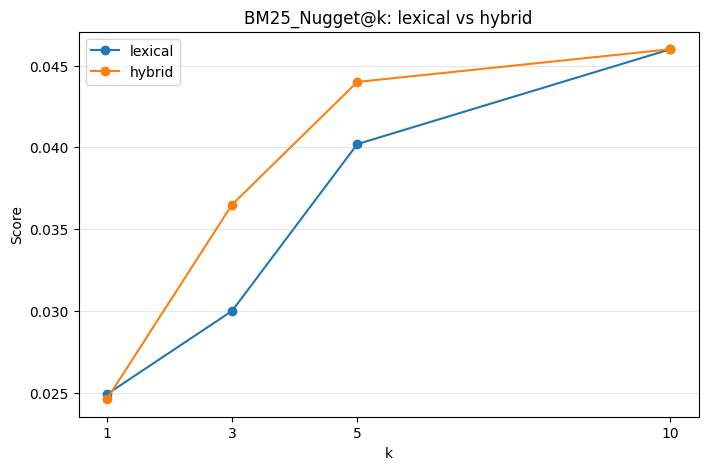

In [13]:
metric_to_plot = "BM25_Nugget@k"

metric_df = df[df["metric_name"] == metric_to_plot].sort_values("k")

plt.figure(figsize=(8, 5))
plt.plot(metric_df["k"], metric_df["baseline_score"], marker="o", label=metric_df["baseline_run"].iloc[0])
plt.plot(metric_df["k"], metric_df["compared_score"], marker="o", label=metric_df["compared_run"].iloc[0])
plt.xlabel("k")
plt.ylabel("Score")
plt.title(f"{metric_to_plot}: lexical vs hybrid")
plt.xticks(metric_df["k"])
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

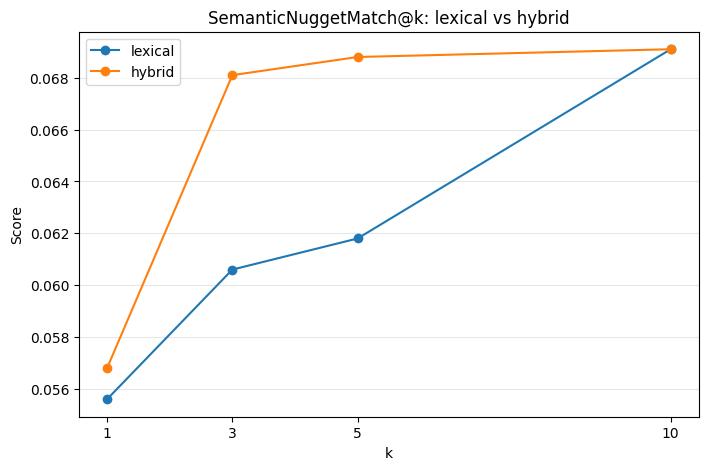

In [14]:
metric_to_plot = "SemanticNuggetMatch@k"

metric_df = df[df["metric_name"] == metric_to_plot].sort_values("k")

plt.figure(figsize=(8, 5))
plt.plot(metric_df["k"], metric_df["baseline_score"], marker="o", label=metric_df["baseline_run"].iloc[0])
plt.plot(metric_df["k"], metric_df["compared_score"], marker="o", label=metric_df["compared_run"].iloc[0])
plt.xlabel("k")
plt.ylabel("Score")
plt.title(f"{metric_to_plot}: lexical vs hybrid")
plt.xticks(metric_df["k"])
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 6. Plot delta by k for one metric

Positive values mean the compared method improved over the baseline. Negative values mean it performed worse.

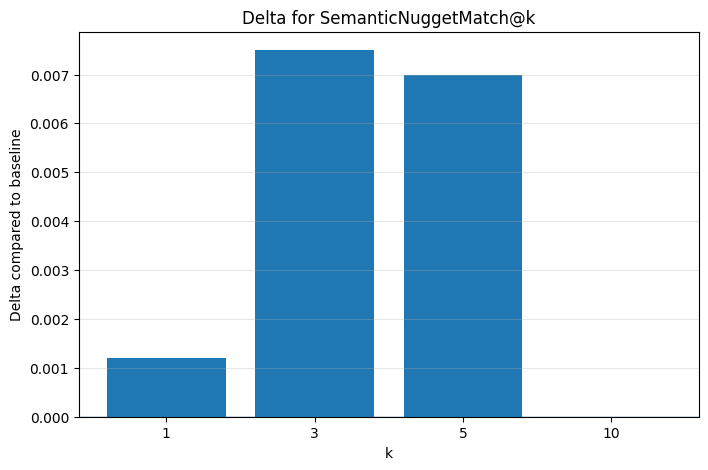

In [7]:
metric_to_plot = "SemanticNuggetMatch@k"

metric_df = df[df["metric_name"] == metric_to_plot].sort_values("k")

plt.figure(figsize=(8, 5))
plt.bar(metric_df["k"].astype(str), metric_df["delta"])
plt.axhline(0, linewidth=1)
plt.xlabel("k")
plt.ylabel("Delta compared to baseline")
plt.title(f"Delta for {metric_to_plot}")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 7. Plot all metric deltas

This gives a compact overview of where the improved method helps or hurts.

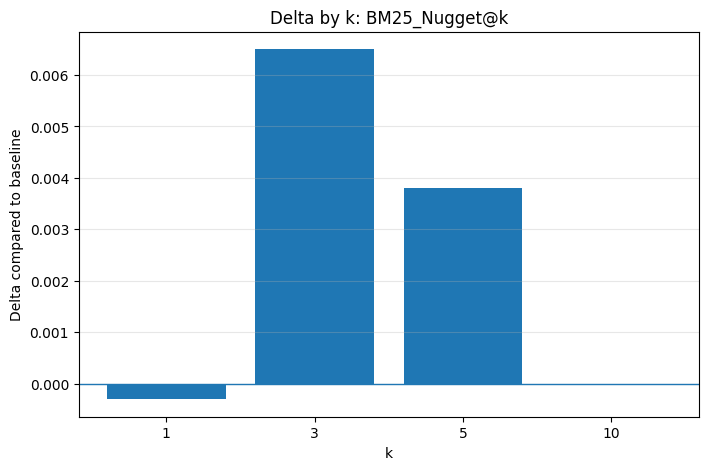

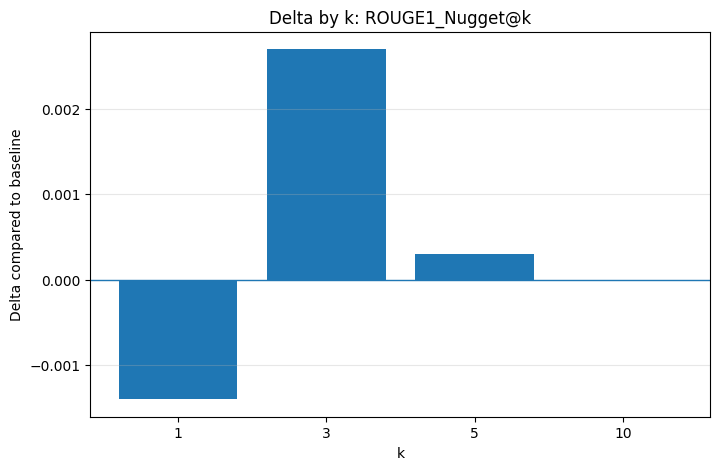

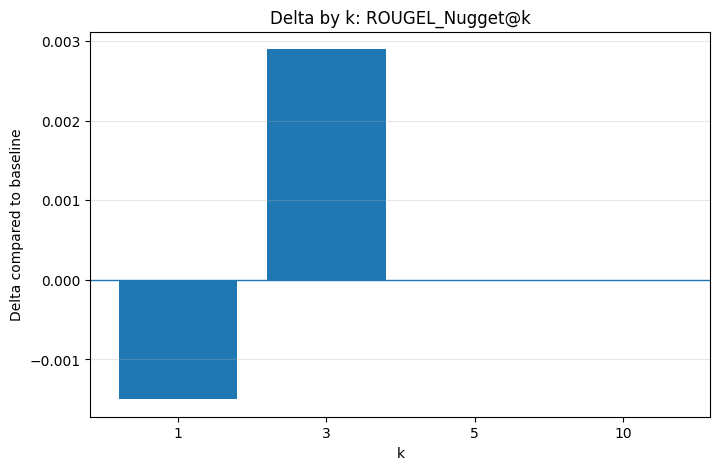

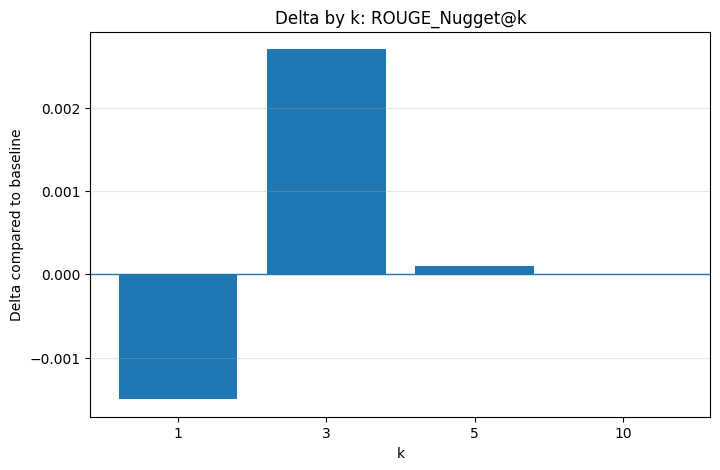

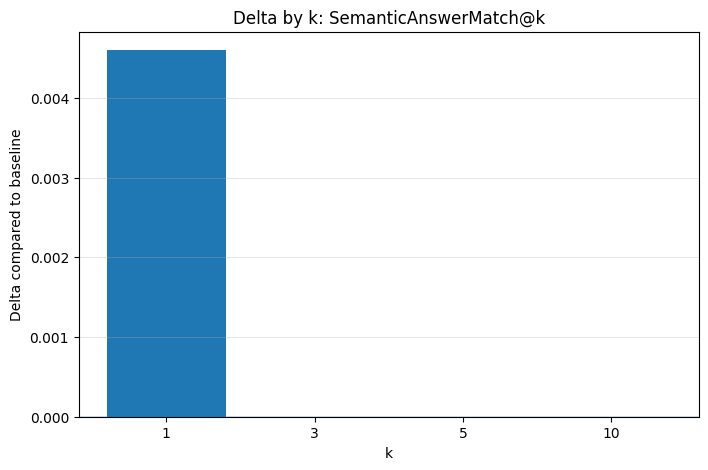

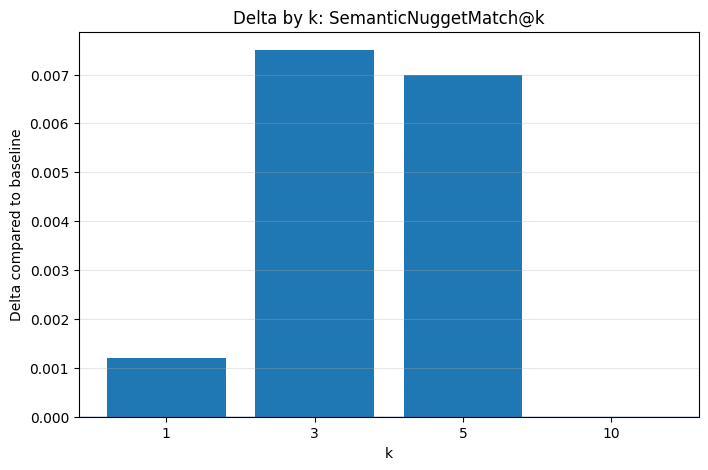

In [8]:
for metric_name in sorted(df["metric_name"].unique()):
    metric_df = df[df["metric_name"] == metric_name].sort_values("k")

    plt.figure(figsize=(8, 5))
    plt.bar(metric_df["k"].astype(str), metric_df["delta"])
    plt.axhline(0, linewidth=1)
    plt.xlabel("k")
    plt.ylabel("Delta compared to baseline")
    plt.title(f"Delta by k: {metric_name}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## 8. Best improvements

These rows show where the compared method improved most over the baseline.

In [9]:
best_improvements = (
    df.sort_values("delta", ascending=False)
      .loc[:, [
          "metric_group",
          "metric_name",
          "k",
          "baseline_score",
          "compared_score",
          "delta",
          "relative_delta_percent",
      ]]
      .head(10)
)

best_improvements

,metric_group,metric_name,k,baseline_score,compared_score,delta,relative_delta_percent
21,semantic,SemanticNuggetMatch@k,3,0.0606,0.0681,0.0075,12.38
22,semantic,SemanticNuggetMatch@k,5,0.0618,0.0688,0.0070,11.33
1,lexical,BM25_Nugget@k,3,0.0300,0.0365,0.0065,21.67
16,semantic,SemanticAnswerMatch@k,1,0.1060,0.1106,0.0046,4.34
2,lexical,BM25_Nugget@k,5,0.0402,0.0440,0.0038,9.45
9,lexical,ROUGEL_Nugget@k,3,0.0152,0.0181,0.0029,19.08
5,lexical,ROUGE1_Nugget@k,3,0.0179,0.0206,0.0027,15.08
13,lexical,ROUGE_Nugget@k,3,0.0166,0.0193,0.0027,16.27
20,semantic,SemanticNuggetMatch@k,1,0.0556,0.0568,0.0012,2.16
6,lexical,ROUGE1_Nugget@k,5,0.0216,0.0219,0.0003,1.39


## 9. Regressions

These rows show where the compared method became worse than the baseline.

In [10]:
regressions = (
    df[df["delta"] < 0]
      .sort_values("delta", ascending=True)
      .loc[:, [
          "metric_group",
          "metric_name",
          "k",
          "baseline_score",
          "compared_score",
          "delta",
          "relative_delta_percent",
      ]]
)

regressions

,metric_group,metric_name,k,baseline_score,compared_score,delta,relative_delta_percent
12,lexical,ROUGE_Nugget@k,1,0.0150,0.0135,-0.0015,-10.00
8,lexical,ROUGEL_Nugget@k,1,0.0140,0.0125,-0.0015,-10.71
4,lexical,ROUGE1_Nugget@k,1,0.0160,0.0146,-0.0014,-8.75
0,lexical,BM25_Nugget@k,1,0.0249,0.0246,-0.0003,-1.20


## 10. Thesis interpretation helper

This cell creates a short, data-driven interpretation that can be used as a starting point for writing.

In [11]:
positive_rows = df[df["delta"] > 0]
negative_rows = df[df["delta"] < 0]
neutral_rows = df[df["delta"] == 0]

print("Comparison summary")
print("------------------")
print(f"Total metric rows: {len(df)}")
print(f"Improved rows: {len(positive_rows)}")
print(f"Regressed rows: {len(negative_rows)}")
print(f"Unchanged rows: {len(neutral_rows)}")

if not positive_rows.empty:
    best_row = positive_rows.sort_values("delta", ascending=False).iloc[0]
    print()
    print("Largest absolute improvement:")
    print(
        f"{best_row['metric_name']} at k={int(best_row['k'])}: "
        f"{best_row['baseline_score']:.4f} -> {best_row['compared_score']:.4f} "
        f"(delta={best_row['delta']:.4f}, relative={best_row['relative_delta_percent']:.2f}%)"
    )

if not negative_rows.empty:
    worst_row = negative_rows.sort_values("delta", ascending=True).iloc[0]
    print()
    print("Largest regression:")
    print(
        f"{worst_row['metric_name']} at k={int(worst_row['k'])}: "
        f"{worst_row['baseline_score']:.4f} -> {worst_row['compared_score']:.4f} "
        f"(delta={worst_row['delta']:.4f}, relative={worst_row['relative_delta_percent']:.2f}%)"
    )

print()
print("Suggested interpretation:")
print(
    "The improved reranker should be interpreted by metric and k. "
    "Improvements at smaller k values indicate better early precision, while "
    "improvements at larger k values indicate better coverage within the returned evidence pack. "
    "Rows with zero change usually mean that both methods retrieved the same best-matching evidence by that cutoff."
)

Comparison summary
------------------
Total metric rows: 24
Improved rows: 11
Regressed rows: 4
Unchanged rows: 9

Largest absolute improvement:
SemanticNuggetMatch@k at k=3: 0.0606 -> 0.0681 (delta=0.0075, relative=12.38%)

Largest regression:
ROUGE_Nugget@k at k=1: 0.0150 -> 0.0135 (delta=-0.0015, relative=-10.00%)

Suggested interpretation:
The improved reranker should be interpreted by metric and k. Improvements at smaller k values indicate better early precision, while improvements at larger k values indicate better coverage within the returned evidence pack. Rows with zero change usually mean that both methods retrieved the same best-matching evidence by that cutoff.


## 11. Save a cleaned comparison table for figures/reporting

This optional output can be used in the thesis or copied into another reporting tool.

In [ ]:
clean_output_path = COMPARISON_CSV.parent / "method_comparison_clean.csv"

comparison_table.to_csv(clean_output_path, index=False, encoding="utf-8")

print(f"Saved cleaned comparison table to: {clean_output_path}")